In [1]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

print("Dataset path:", path)
print("Files:", os.listdir(path))

df = pd.read_csv(f"{path}/bank.csv", sep=",")

df.head()

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
Dataset path: /kaggle/input/bank-marketing-dataset
Files: ['bank.csv']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [2]:
print("Dataset Shape:", df.shape)

print("\nFeature Data Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (11162, 17)

Feature Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 

In [3]:
print("Target Distribution:")
print(df["deposit"].value_counts())

print("\nTarget Distribution (%):")
print(df["deposit"].value_counts(normalize=True) * 100)

Target Distribution:
deposit
no     5873
yes    5289
Name: count, dtype: int64

Target Distribution (%):
deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64


In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Number of Duplicate Rows:
0


In [ ]:
#df = df.drop_duplicates()

#print("Dataset shape after removing duplicates:", df.shape)

In [5]:
# Features
X = df.drop("deposit", axis=1)

# Target
y = df["deposit"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11162, 16)
y shape: (11162,)


In [6]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30, # basicallly validation + testing is 30%
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Temporary (validation + testing) set:", X_temp.shape)

Training set: (7813, 16)
Temporary (validation + testing) set: (3349, 16)


In [8]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (7813, 16)
Validation set: (1674, 16)
Test set: (1675, 16)


In [9]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
deposit
no     52.617432
yes    47.382568
Name: proportion, dtype: float64

Validation target distribution:
deposit
no     52.628435
yes    47.371565
Name: proportion, dtype: float64

Test target distribution:
deposit
no     52.597015
yes    47.402985
Name: proportion, dtype: float64


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), #because median is more robust to outliers
    ("scaler", StandardScaler())
])

# categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [11]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (7813, 51)
Processed validation shape: (1674, 51)
Processed test shape: (1675, 51)


### FEATURE ENGINEERING DECISIONS:

1. Target:
   - 'y' is the target variable.
   - It represents a classification problem: yes/no.

2. Duplicates:
   - Duplicate rows were removed to avoid repeated observations
     having extra influence on the model.

3. Missing Values:
   - Numerical features: median imputation.
   - Categorical features: most frequent value imputation.

4. Categorical Features:
   - One-Hot Encoding was used.
   - handle_unknown='ignore' prevents errors if new categories
     appear in validation or test data.

5. Numerical Features:
   - StandardScaler was applied.
   - Scaling is useful for algorithms dependent on feature magnitude
     or distance, such as Logistic Regression, kNN, and SVM.

6. Data Splitting:
   - 70% training, 15% validation, and 15% test.
   - random_state=42 ensures reproducible results.
   - Stratification was used because the target classes are imbalanced.

7. Data Leakage Prevention:
   - The preprocessing pipeline was fitted only on the training data.
   - Validation and test sets were transformed using the training-fitted pipeline.

In [12]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train_processed, y_train)

print("Gradient Boosting model training done!!")

Gradient Boosting model training done!!


In [13]:
from sklearn.metrics import accuracy_score

y_train_pred_gb = gb.predict(X_train_processed)

y_val_pred_gb = gb.predict(X_val_processed)

train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
val_accuracy_gb = accuracy_score(y_val, y_val_pred_gb)

print("gradient boosting performance:")
print(f"training accuracy: {train_accuracy_gb:.4f}")
print(f"validation accuracy: {val_accuracy_gb:.4f}")

gradient boosting performance:
training accuracy: 0.8558
validation accuracy: 0.8578


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

accuracy_gb = accuracy_score(y_val, y_val_pred_gb)

precision_gb = precision_score(
    y_val,
    y_val_pred_gb,
    pos_label="yes"
)

recall_gb = recall_score(
    y_val,
    y_val_pred_gb,
    pos_label="yes"
)

f1_gb = f1_score(
    y_val,
    y_val_pred_gb,
    pos_label="yes"
)

print("gradient boosting metrics")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1-score: {f1_gb:.4f}")

gradient boosting metrics
Accuracy: 0.8578
Precision: 0.8413
Recall: 0.8625
F1-score: 0.8518


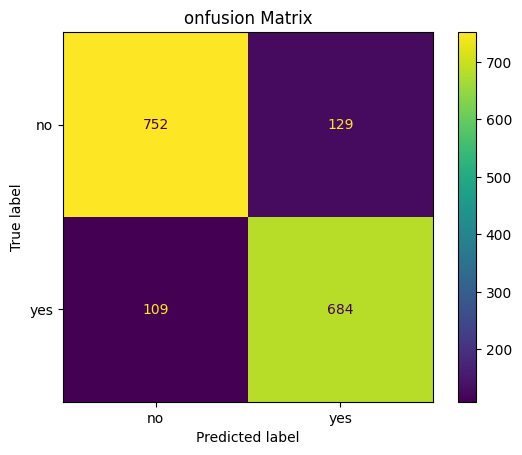

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_gb)

plt.title("onfusion Matrix")
plt.show()

Validation ROC-AUC: 0.9312


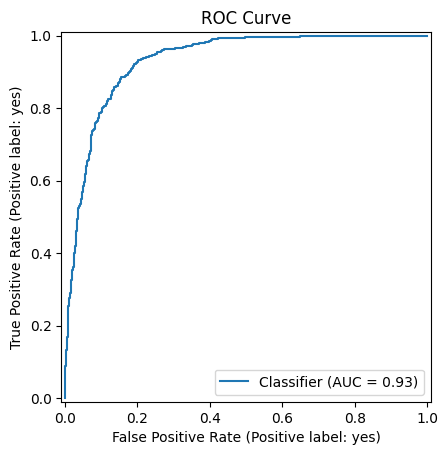

In [16]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

#probability of the positive clas
y_val_prob_gb = gb.predict_proba(X_val_processed)[:, 1]

roc_auc_gb = roc_auc_score(y_val, y_val_prob_gb)

print(f"Validation ROC-AUC: {roc_auc_gb:.4f}")

RocCurveDisplay.from_predictions(
    y_val,
    y_val_prob_gb,
    pos_label="yes"
)

plt.title("ROC Curve")
plt.show()

In [17]:
#training newmodel for training time
import time
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

start_time = time.perf_counter()

gb.fit(X_train_processed, y_train)

training_time_gb = time.perf_counter() - start_time

print(f"Gradient Boosting Training Time: {training_time_gb:.6f} secs")

Gradient Boosting Training Time: 2.229313 secs


In [18]:
start_time = time.perf_counter()

y_val_pred_gb = gb.predict(X_val_processed)

prediction_time_gb = time.perf_counter() - start_time

print(f"Prediction Time: {prediction_time_gb:.6f} s")

Prediction Time: 0.007424 s


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
start_time = time.perf_counter()
rf.fit(X_train_processed, y_train)
training_time_rf = time.perf_counter() - start_time

print(f"random forest training time: {training_time_rf:.6f} secs")
print("random forest trained successfully!")

random forest training time: 2.321032 secs
random forest trained successfully!


In [24]:
from sklearn.metrics import accuracy_score

y_train_pred_rf = rf.predict(X_train_processed)
y_val_pred_rf = rf.predict(X_val_processed)

train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)

print(f"Training accuracy: {train_accuracy_rf:.4f}")
print(f"Validation accuracy: {val_accuracy_rf:.4f}")

Training accuracy: 1.0000
Validation accuracy: 0.8644


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_rf = precision_score(y_val, y_val_pred_rf, pos_label="yes")
recall_rf = recall_score(y_val, y_val_pred_rf, pos_label="yes")
f1_rf = f1_score(y_val, y_val_pred_rf, pos_label="yes")

print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

Precision: 0.8369
Recall: 0.8865
F1-score: 0.8610


In [26]:
from sklearn.metrics import roc_auc_score

y_val_prob_rf = rf.predict_proba(X_val_processed)[:, 1]

roc_auc_rf = roc_auc_score(y_val, y_val_prob_rf)

print(f"random forest ROC AUC: {roc_auc_rf:.4f}")

random forest ROC AUC: 0.9272


In [27]:
start_time = time.perf_counter()

y_val_pred_rf = rf.predict(X_val_processed)

prediction_time_rf = time.perf_counter() - start_time

print(f"prediction time: {prediction_time_rf:.6f} secs")

prediction time: 0.065950 secs


**Gradient Boosting vs Random Forest**

In [28]:
import pandas as pd

comparison_rf_gb = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],

    "Training Accuracy": [
        train_accuracy_rf,
        train_accuracy_gb
    ],

    "Validation Accuracy": [
        val_accuracy_rf,
        val_accuracy_gb
    ],

    "Precision": [
        precision_rf,
        precision_gb
    ],

    "Recall": [
        recall_rf,
        recall_gb
    ],

    "F1-score": [
        f1_rf,
        f1_gb
    ],

    "ROC-AUC": [
        roc_auc_rf,
        roc_auc_gb
    ],

    "Training Time (seconds)": [
        training_time_rf,
        training_time_gb
    ],

    "Prediction Time (seconds)": [
        prediction_time_rf,
        prediction_time_gb
    ]
})

comparison_rf_gb

,Model,Training Accuracy,Validation Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time (seconds),Prediction Time (seconds)
0,Random Forest,1.000000,0.864397,0.836905,0.886507,0.860992,0.927240,2.321032,0.065950
1,Gradient Boosting,0.855753,0.857826,0.841328,0.862547,0.851806,0.931244,2.229313,0.007424


In [29]:
if val_accuracy_rf > val_accuracy_gb:
    print("random forest performed better based on validation accuracy")
elif val_accuracy_gb > val_accuracy_rf:
    print("gradient boosting performed better based on validation accuracy")
else:
    print("Both models have same validation accuracy")

random forest performed better based on validation accuracy
